# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

<style>
/* Wrap code cells in HTML/PDF export */
pre, code {
  white-space: pre-wrap !important;
  word-wrap: break-word !important;
}
</style>


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani

### Use GPU

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [4]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [5]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

### Batching

In [6]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [7]:
class AtomicNet(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [8]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.1107, device='cuda:0', grad_fn=<MseLossBackward0>)


## Checkpoint 2 : Network construction and workflow development ##

In [9]:
import matplotlib.pyplot as plt
import copy

In [20]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")

        self.l2 = l2  
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=self.l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True, max_train_batches=None, max_val_batches=None):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        weights = copy.deepcopy(self.model.state_dict())
        
        for i in tqdm(range(self.epoch), leave=True):
            self.model.train()
            train_epoch_loss = 0.0
            total_samples = 0
            
            for batch_idx, train_data_batch in enumerate(train_data_loader):
                if max_train_batches is not None and batch_idx >= max_train_batches:
                    break
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                batch_importance = species.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                total_samples += batch_importance

            train_epoch_loss /= total_samples
            
            # # use the self.evaluate to get loss on the validation set 
            # val_epoch_loss = self.evaluate(val_data, draw_plot=False, max_batches=max_val_batches)
            
            # # append the losses
            # train_loss_list.append(train_epoch_loss)
            # val_loss_list.append(val_epoch_loss)

            # print(f"Epoch {i+1}/{self.epoch} | Train Loss: {train_epoch_loss:.6f} | Val Loss: {val_epoch_loss:.6f}")
            
            # if early_stop:
            #     if val_epoch_loss < lowest_val_loss:
            #         lowest_val_loss = val_epoch_loss
            #         weights = copy.deepcopy(self.model.state_dict())

            # Checkpoint 5 updated code for training all data:
            if val_data is not None:
                val_epoch_loss = self.evaluate(val_data, draw_plot=False, max_batches=max_val_batches)
                val_loss_list.append(val_epoch_loss)
                print(f"Epoch {i+1}/{self.epoch} | Train Loss: {train_epoch_loss:.6f} | Val Loss: {val_epoch_loss:.6f}")

                if early_stop and val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = copy.deepcopy(self.model.state_dict())
            else:
                print(f"Epoch {i+1}/{self.epoch} | Train Loss: {train_epoch_loss:.6f}")

            train_loss_list.append(train_epoch_loss)
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='Train')
            # ax.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='Validation')
            if len(val_loss_list) > 0:
                ax.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, max_batches=None, return_mae=False, return_rmse=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        total_samples = 0
        
        if draw_plot or return_mae or return_rmse:
            true_energies_all = []
            pred_energies_all = []

        self.model.eval()
        with torch.no_grad():
            for batch_idx, batch_data in enumerate(data_loader):
                if max_batches is not None and batch_idx >= max_batches:
                    break
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = species.shape[0]
                total_loss += batch_loss.item() * batch_importance
                total_samples += batch_importance
                
                if draw_plot or return_mae or return_rmse:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())
                    
        total_loss /= total_samples

        if draw_plot or return_mae or return_rmse:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            rmse = np.sqrt(np.mean((true_energies_all - pred_energies_all) ** 2)) * hartree2kcalmol
            
            if draw_plot:
                fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
                ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f}, RMSE: {rmse:.2f} kcal/mol", s=2)
                ax.set_xlabel("Ground Truth")
                ax.set_ylabel("Predicted")
                xmin, xmax = ax.get_xlim()
                ymin, ymax = ax.get_ylim()
                vmin, vmax = min(xmin, ymin), max(xmax, ymax)
                ax.set_xlim(vmin, vmax)
                ax.set_ylim(vmin, vmax)
                ax.plot([vmin, vmax], [vmin, vmax], color='red')
                ax.legend()

            if return_mae and return_rmse:
                return mae, rmse

            if return_mae:
                return mae
                
            if return_rmse:
                return rmse
            
        return total_loss

### Train a small subset of the data: ###

In [12]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


 33%|███▎      | 1/3 [00:24<00:48, 24.32s/it]

Epoch 1/3 | Train Loss: 0.014665 | Val Loss: 0.013151


 67%|██████▋   | 2/3 [00:26<00:11, 11.44s/it]

Epoch 2/3 | Train Loss: 0.010882 | Val Loss: 0.010076


100%|██████████| 3/3 [00:30<00:00, 10.03s/it]

Epoch 3/3 | Train Loss: 0.008640 | Val Loss: 0.008183


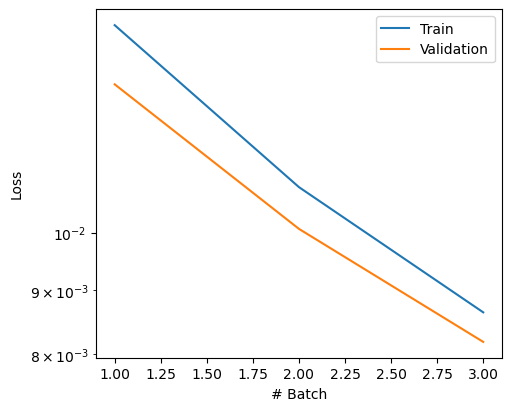

In [13]:
trainer = ANITrainer(
    model,
    batch_size=128,
    learning_rate=1e-3,
    epoch=3,
    l2=1e-5
)

train_loss_list, val_loss_list = trainer.train(
    train_data,
    val_data,
    early_stop=True,
    draw_curve=True,
    max_train_batches=5,
    max_val_batches=2
)

0.008182576857507229

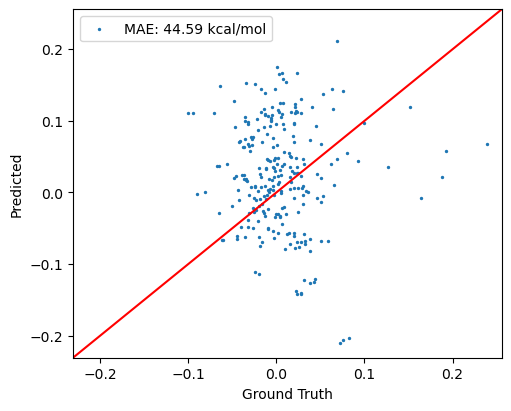

In [14]:
trainer.evaluate(val_data, draw_plot=True, max_batches=2)

The ANI model was trained using MSE loss (for solving regression problems) and Adam optimizer (because it works more efficiently, the tutorial also used Adam as the default optimizer). 

Both training and validation losses decrease over epochs, indicating that the model is learning.

The evaluation shows a relatively high MAE(Mean Absolute Error more sutable for evaluation), which is expected due to training on a small subset with small amount of epochs. 

So, overall, the training and evaluation pipeline works correctly.

## Checkpoint 3: Regularization strategies and hyperparameter tuning

In [10]:
# hidden_dims = [128, 256]
# learning_rates = [1e-3, 1e-4]
# l2_values = [0, 1e-5]
# epochs = 10

hidden_dims = [64, 128, 256]
learning_rates = [1e-3, 1e-4]
l2_values = [0, 1e-5]
epochs = 5             

In [11]:
results = []

for hidden_dim in hidden_dims:
    for lr in learning_rates:
        for l2 in l2_values:

            print(f"\nRunning: hidden={hidden_dim}, lr={lr}, l2={l2}")

            # reinitialize model
            net_H = AtomicNet(hidden_dim)
            net_C = AtomicNet(hidden_dim)
            net_N = AtomicNet(hidden_dim)
            net_O = AtomicNet(hidden_dim)

            ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
            model = nn.Sequential(aev_computer, ani_net).to(device)

            trainer = ANITrainer(
                model,
                batch_size=256,
                learning_rate=lr,
                epoch=epochs,
                l2=l2
            )

            train_loss, val_loss = trainer.train(
                train_data,
                val_data,
                draw_curve=False
            )

            final_val_loss = val_loss[-1]

            train_mae = trainer.evaluate(train_data, return_mae=True)
            val_mae = trainer.evaluate(val_data, return_mae=True)

            print(f"Train MAE: {train_mae:.2f} kcal/mol | Val MAE: {val_mae:.2f} kcal/mol")

            results.append({
                "hidden_dim": hidden_dim,
                "learning_rate": lr,
                "l2": l2,
                "final_val_loss": final_val_loss,
                "train_mae": train_mae,
                "val_mae": val_mae
            })


Running: hidden=64, lr=0.001, l2=0
Sequential - Number of parameters: 98820
Initialize training data...


 20%|██        | 1/5 [01:41<06:45, 101.47s/it]

Epoch 1/5 | Train Loss: 0.000140 | Val Loss: 0.000032


 40%|████      | 2/5 [03:23<05:05, 101.71s/it]

Epoch 2/5 | Train Loss: 0.000024 | Val Loss: 0.000020


...

 80%|████████  | 4/5 [11:38<02:56, 176.94s/it]

Epoch 4/5 | Train Loss: 0.000018 | Val Loss: 0.000014


100%|██████████| 5/5 [14:48<00:00, 177.62s/it]

Epoch 5/5 | Train Loss: 0.000016 | Val Loss: 0.000013


Train MAE: 1.43 kcal/mol | Val MAE: 1.44 kcal/mol


In [12]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="val_mae").reset_index(drop=True)
df_results

,hidden_dim,learning_rate,l2,final_val_loss,train_mae,val_mae
0,64,0.0010,0.00000,0.000005,0.979937,0.987342
1,256,0.0010,0.00000,0.000005,0.983503,0.994686
2,128,0.0010,0.00000,0.000006,1.146211,1.152172
3,256,0.0001,0.00000,0.000011,1.189181,1.201160
4,128,0.0001,0.00000,0.000010,1.326049,1.346883
5,64,0.0001,0.00001,0.000013,1.425070,1.433479
6,256,0.0001,0.00001,0.000013,1.431747,1.442144
7,64,0.0001,0.00000,0.000014,1.515486,1.535375
8,128,0.0010,0.00001,0.000015,1.570841,1.579133
9,128,0.0001,0.00001,0.000017,1.688814,1.693933


In [13]:
best_config = df_results.loc[df_results["val_mae"].idxmin()]
print("Best configuration:")
print(best_config.to_string())

Best configuration:
hidden_dim        64.000000
learning_rate      0.001000
l2                 0.000000
final_val_loss     0.000005
train_mae          0.979937
val_mae            0.987342


Sequential - Number of parameters: 98820
Initialize training data...


 20%|██        | 1/5 [01:46<07:05, 106.27s/it]

Epoch 1/5 | Train Loss: 0.000812 | Val Loss: 0.000021


 40%|████      | 2/5 [03:34<05:22, 107.46s/it]

Epoch 2/5 | Train Loss: 0.000031 | Val Loss: 0.000023


...

Epoch 3/5 | Train Loss: 0.000029 | Val Loss: 0.000017


 80%|████████  | 4/5 [07:08<01:47, 107.27s/it]

Epoch 4/5 | Train Loss: 0.000019 | Val Loss: 0.000012


100%|██████████| 5/5 [08:58<00:00, 107.64s/it]

Epoch 5/5 | Train Loss: 0.000014 | Val Loss: 0.000006


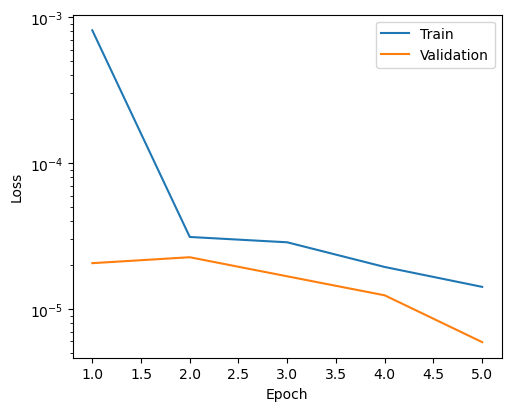

In [11]:
# best_hidden = int(best_config["hidden_dim"])
# best_lr = float(best_config["learning_rate"])
# best_l2 = float(best_config["l2"])
# OUTPUTS WERE OBTAINED FROM LAST SAVIO SESSION

best_hidden = 64
best_lr = 1e-3
best_l2 = 0

# Rebuild model
net_H = AtomicNet(best_hidden)
net_C = AtomicNet(best_hidden)
net_N = AtomicNet(best_hidden)
net_O = AtomicNet(best_hidden)

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
best_model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(
    best_model,
    batch_size=256,
    learning_rate=best_lr,
    epoch=5,
    l2=best_l2
)

train_loss, val_loss = trainer.train(
    train_data,
    val_data,
    draw_curve=True
)

Test MAE: 1.10 kcal/mol


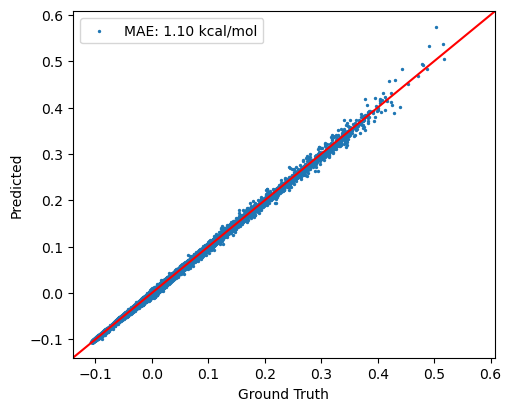

In [12]:
test_mae = trainer.evaluate(test_data, draw_plot=True, return_mae=True)
print(f"Test MAE: {test_mae:.2f} kcal/mol")

Checkpoint 3 evaluated multiple combinations of model architecture(64, 128, 256), learning rate(1e-3 and 1e-4), and L2 regularization(0 and 1e-5) using more data than in previous checkpoints.

Based on the outputs, the best-performing model is the one with hidden dimension of 64, a learning rate of 1e-3, and no L2 regularization because configuration produced the lowest validation MAE (approximately 0.99 kcal/mol). Increasing the model size to 128 or 256 did not improve performance and sometimes led to worse generalization. Also, adding L2 regularization slightly increased validation error, which suggest that regularization was not necessary good for this model and dataset. The results also showing that learning rate of 1e-3 performed better than 1e-4, which suggest that higher learning rate helped the model converge more effectively.

The model of my choice: 
- hidden_dim = 64  
- learning_rate = 1e-3  
- l2 = 0
   
Since this model achieved the lowest validation error, I retrained the model using these hyperparameters. Both training and validation losses decreased smoothly, indicating stable learning without overfitting, which demonstrated good generalization to unseen data. The model was then evaluated on the test set, and the MAE is around 1.10 kcal/mol. The predicted vs. true energy plot shows that most points lie close to y = x (perfect prediction), indicating that the predicted values are very close to the true values, so the model is making accurate predictions with low error. That's why i chose this model(hidden_dim = 64, learning_rate = 1e-3, l2 = 0) as the final model.

## Checkpoint4: Final production mode (Multiple runs and N-fold cross-validation)

Best configuration from Checkpoint 3:
- hidden_dim = 64
- learning_rate = 1e-3
- l2 = 0

### Multiple runs (5 runs conducted):

In [10]:
def build_ani_model(hidden_dim):
    net_H = AtomicNet(hidden_dim)
    net_C = AtomicNet(hidden_dim)
    net_N = AtomicNet(hidden_dim)
    net_O = AtomicNet(hidden_dim)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(aev_computer, ani_net).to(device)
    return model

In [11]:
def run_single_training(train_data, val_data, test_data,
                        hidden_dim=64, learning_rate=1e-3, l2=0,
                        batch_size=256, epochs=5,
                        draw_curve=False):
    
    model = build_ani_model(hidden_dim)

    trainer = ANITrainer(
        model=model,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epoch=epochs,
        l2=l2
    )

    train_losses, val_losses = trainer.train(
        train_data=train_data,
        val_data=val_data,
        draw_curve=draw_curve
    )

    train_mae = trainer.evaluate(train_data, return_mae=True)
    val_mae = trainer.evaluate(val_data, return_mae=True)
    test_mae = trainer.evaluate(test_data, return_mae=True)

    return {
        "model": model,
        "trainer": trainer,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_mae": train_mae,
        "val_mae": val_mae,
        "test_mae": test_mae
    }

In [12]:
num_runs = 5

multi_run_results = []

for run_idx in range(num_runs):
    print(f"\n===== Run {run_idx + 1}/{num_runs} =====")

    result = run_single_training(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        hidden_dim=64,
        learning_rate=1e-3,
        l2=0,
        batch_size=256,
        epochs=5,
        draw_curve=False
    )

    multi_run_results.append({
        "run": run_idx + 1,
        "train_mae": result["train_mae"],
        "val_mae": result["val_mae"],
        "test_mae": result["test_mae"]
    })


===== Run 1/5 =====
Sequential - Number of parameters: 98820
Initialize training data...


 20%|██        | 1/5 [00:29<01:59, 29.86s/it]

Epoch 1/5 | Train Loss: 0.000746 | Val Loss: 0.000023


 40%|████      | 2/5 [00:55<01:21, 27.22s/it]

Epoch 2/5 | Train Loss: 0.000024 | Val Loss: 0.000045


...

Epoch 3/5 | Train Loss: 0.000015 | Val Loss: 0.000025


 80%|████████  | 4/5 [01:45<00:26, 26.44s/it]

Epoch 4/5 | Train Loss: 0.000011 | Val Loss: 0.000016


100%|██████████| 5/5 [02:10<00:00, 26.10s/it]

Epoch 5/5 | Train Loss: 0.000009 | Val Loss: 0.000009


In [13]:
import pandas as pd

df_multi_runs = pd.DataFrame(multi_run_results)
df_multi_runs

,run,train_mae,val_mae,test_mae
0,1,2.054431,2.050165,2.054231
1,2,2.229321,2.226996,2.232416
2,3,1.662945,1.660891,1.671328
3,4,1.249773,1.244688,1.258913
4,5,1.578277,1.576451,1.581804


In [14]:
print("Multiple-run summary:")
print(f"Mean train MAE: {df_multi_runs['train_mae'].mean():.3f} ± {df_multi_runs['train_mae'].std():.3f} kcal/mol")
print(f"Mean val   MAE: {df_multi_runs['val_mae'].mean():.3f} ± {df_multi_runs['val_mae'].std():.3f} kcal/mol")
print(f"Mean test  MAE: {df_multi_runs['test_mae'].mean():.3f} ± {df_multi_runs['test_mae'].std():.3f} kcal/mol")

Multiple-run summary:
Mean train MAE: 1.755 ± 0.390 kcal/mol
Mean val   MAE: 1.752 ± 0.391 kcal/mol
Mean test  MAE: 1.760 ± 0.387 kcal/mol


### N-fold cross-validation (5-fold used):

In [15]:
dev_data_list = list(train_data) + list(val_data)
print("Number of development samples:", len(dev_data_list))
print("Number of test samples:", len(list(test_data)))

Number of development samples: 778407
Number of test samples: 86491


In [16]:
from sklearn.model_selection import KFold

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [17]:
cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(dev_data_list), start=1):
    print(f"\n===== Fold {fold_idx}/{k} =====")

    fold_train_list = [dev_data_list[i] for i in train_idx]
    fold_val_list = [dev_data_list[i] for i in val_idx]

    fold_train_data = torchani.data.TransformableIterable(fold_train_list)
    fold_val_data = torchani.data.TransformableIterable(fold_val_list)

    model = build_ani_model(hidden_dim=64)

    trainer = ANITrainer(
        model=model,
        batch_size=256,
        learning_rate=1e-3,
        epoch=5,
        l2=0
    )

    train_losses, val_losses = trainer.train(
        train_data=fold_train_data,
        val_data=fold_val_data,
        draw_curve=False
    )

    fold_train_mae = trainer.evaluate(fold_train_data, return_mae=True)
    fold_val_mae = trainer.evaluate(fold_val_data, return_mae=True)

    cv_results.append({
        "fold": fold_idx,
        "train_mae": fold_train_mae,
        "val_mae": fold_val_mae
    })


===== Fold 1/5 =====
Sequential - Number of parameters: 98820
Initialize training data...


 20%|██        | 1/5 [00:38<02:34, 38.61s/it]

Epoch 1/5 | Train Loss: 0.000254 | Val Loss: 0.000022


 40%|████      | 2/5 [01:01<01:27, 29.29s/it]

Epoch 2/5 | Train Loss: 0.000032 | Val Loss: 0.000022


...

Epoch 3/5 | Train Loss: 0.000025 | Val Loss: 0.000016


 80%|████████  | 4/5 [01:46<00:26, 26.85s/it]

Epoch 4/5 | Train Loss: 0.000018 | Val Loss: 0.000028


100%|██████████| 5/5 [02:11<00:00, 26.28s/it]

Epoch 5/5 | Train Loss: 0.000014 | Val Loss: 0.000014


In [19]:
df_cv = pd.DataFrame(cv_results)
df_cv

,fold,train_mae,val_mae
0,1,1.079807,1.085786
1,2,1.327407,1.330063
2,3,1.523374,1.532403
3,4,1.243466,1.248134
4,5,1.998620,1.996871


In [20]:
print("Cross-validation summary:")
print(f"Mean train MAE: {df_cv['train_mae'].mean():.3f} ± {df_cv['train_mae'].std():.3f} kcal/mol")
print(f"Mean val   MAE: {df_cv['val_mae'].mean():.3f} ± {df_cv['val_mae'].std():.3f} kcal/mol")

Cross-validation summary:
Mean train MAE: 1.435 ± 0.354 kcal/mol
Mean val   MAE: 1.439 ± 0.351 kcal/mol


### Summary:

In [21]:
summary = pd.DataFrame({
    "Experiment": ["Multiple Runs", "5-Fold CV"],
    "mean_Train_MAE": [
        df_multi_runs["train_mae"].mean(),
        df_cv["train_mae"].mean()
    ],
    "std_Train_MAE": [
        df_multi_runs["train_mae"].std(),
        df_cv["train_mae"].std()
    ],
    "mean_Val_MAE": [
        df_multi_runs["val_mae"].mean(),
        df_cv["val_mae"].mean()
    ],
    "std_Val_MAE": [
        df_multi_runs["val_mae"].std(),
        df_cv["val_mae"].std()
    ],
    "mean_Test_MAE": [
        df_multi_runs["test_mae"].mean(),
        None
    ],
    "std_Test_MAE": [
        df_multi_runs["test_mae"].std(),
        None
    ]
})

summary

,Experiment,mean_Train_MAE,std_Train_MAE,mean_Val_MAE,std_Val_MAE,mean_Test_MAE,std_Test_MAE
0,Multiple Runs,1.754949,0.390384,1.751838,0.390835,1.759738,0.387445
1,5-Fold CV,1.434535,0.353518,1.438651,0.351070,NaN,NaN


The results in Checkpoint 4, using the best model from Checkpoint 3, show that it performs well in both repeated training and cross-validation settings since the selected ANI model remains below the project target of 2 kcal/mol. 

In multiple-run experiment, we kept the same train, validation, and test split, but retrains the model 5 times. The only main thing changing is the random initialization and the randomness during training. Since the MAE is not exactly the same in every run, this tells us the model’s final performance depends somewhat on training randomness. Even so, the model still stays below 2 kcal/mol.

In cross-validation experiment, the algorithm changed the train/validation split itself and each fold trains on a different subset of the data and validates on a different held-out fold, so the exact composition of the training and validation data changes. Under cross-validation, the model still performs fairly well and stays below 2 kcal/mol.

The multiple-run experiment shows that the model’s performance changes slightly in the repeated trainings, which suggests some sensitivity to random initialization and optimization. The cross-validation experiment shows that the model still performs reasonably well when the training and validation split changes, which suggests that the learned patterns generalize well across different data splits. Overall, the model generalizes well enough to support the best configuration chosen from Checkpoint 3 and is sufficient for the final checkpoint.

## Checkpoint5: Final results (Train model with all data and compare your results to what’s reported in the paper) 

In [14]:
best_hidden_dim = 64
best_lr = 1e-3
best_l2 = 0

net_H = AtomicNet(hidden_dim=best_hidden_dim)
net_C = AtomicNet(hidden_dim=best_hidden_dim)
net_N = AtomicNet(hidden_dim=best_hidden_dim)
net_O = AtomicNet(hidden_dim=best_hidden_dim)

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])

final_model = torch.nn.Sequential(
    aev_computer,
    ani_net
).to(device)

final_trainer = ANITrainer(
    final_model,
    batch_size=256,
    learning_rate=best_lr,
    epoch=20,
    l2=best_l2
)

Sequential - Number of parameters: 98820


### Train on all data:

Initialize training data...


  5%|▌         | 1/20 [00:23<07:25, 23.43s/it]

Epoch 1/20 | Train Loss: 0.000106


 10%|█         | 2/20 [00:45<06:48, 22.70s/it]

Epoch 2/20 | Train Loss: 0.000020


...

Epoch 18/20 | Train Loss: 0.000002


 95%|█████████▌| 19/20 [07:08<00:22, 22.69s/it]

Epoch 19/20 | Train Loss: 0.000002


100%|██████████| 20/20 [07:29<00:00, 22.47s/it]

Epoch 20/20 | Train Loss: 0.000002


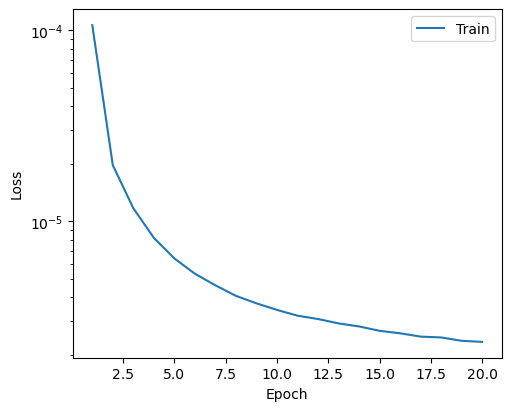

In [15]:
final_train_loss, final_val_loss = final_trainer.train(
    dataset,
    None,
    early_stop=False,
    draw_curve=True
)

In [26]:
print("ANI paper reported model-fit RMSE:")
print("Training RMSE:   1.2 kcal/mol")
print("Validation RMSE: 1.3 kcal/mol")
print("Test RMSE:       1.3 kcal/mol")

ANI paper reported model-fit RMSE:
Training RMSE:   1.2 kcal/mol
Validation RMSE: 1.3 kcal/mol
Test RMSE:       1.3 kcal/mol


Final full-data results:
Final full-data MAE:  0.694 kcal/mol
Final full-data RMSE: 0.893 kcal/mol


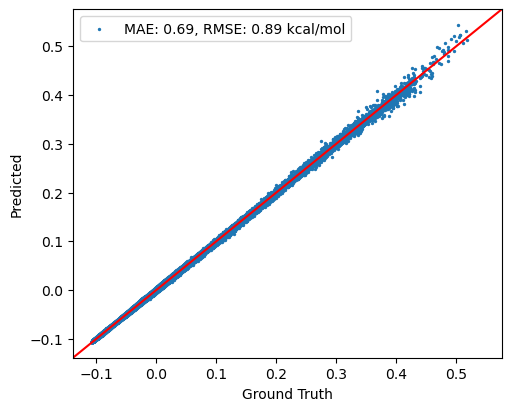

In [27]:
final_full_mae, final_full_rmse = final_trainer.evaluate(
    dataset,
    draw_plot=True,
    return_mae=True,
    return_rmse=True
)

print("Final full-data results:")
print(f"Final full-data MAE:  {final_full_mae:.3f} kcal/mol")
print(f"Final full-data RMSE: {final_full_rmse:.3f} kcal/mol")

The ANI paper reported model-fit RMSE values were 1.2 kcal/mol for training, 1.3 kcal/mol for validation, and 1.3 kcal/mol for testing. This result was obtained by training on 17.2 million conformations from about 58k molecules, using an 80/10/10 train/validation/test split. While the final training from checkpoint 5 obtained a full-data RMSE of 0.893 kcal/mol, lower than what was reported in the ANI paper, it is not an appropriate comparison since checkpoint 5 result was evaluated on the same full dataset used for final training and the paper reports split-based RMSE on a much larger and more diverse ANI-1 dataset. Therefore, a lower RMSE from checkpoint 5 doesn't mean the model is better than the model in the ANI paper, but it did learned the relationship between AEV molecular representations and reference energies effectively.